In [8]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot
from collections import defaultdict
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
from poliastro.extra_util import get_galilean_orbs, ecliptic_slingshot, get_galilean_ephemerides, slingshot_to_another_body
# from poliastro.extra_util import *
solar_system_ephemeris.set("jpl")

from libs import jovian_spenvis_model

In [2]:
# import re
# import numpy as np

# def parse_spenvis_spex(path):
#     with open(path, "r", encoding="utf-8", errors="ignore") as f:
#         lines = f.read().splitlines()

#     energies = None
#     apogee_km = perigee_km = period_hr = None

#     for ln in lines:
#         s = ln.strip()
#         if energies is None and s.startswith("'ENERGY'"):
#             parts = [p.strip() for p in s.split(",")]
#             nE = int(parts[1])
#             energies = np.array([float(x) for x in parts[2:2+nE]], dtype=float)

#         m = re.search(r"Apogee:\s*([0-9.+-Ee]+)\s*km", s)
#         if m: apogee_km = float(m.group(1))
#         m = re.search(r"Perigee:\s*([0-9.+-Ee]+)\s*km", s)
#         if m: perigee_km = float(m.group(1))
#         m = re.search(r"Period:\s*([0-9.+-Ee]+)\s*hrs", s)
#         if m: period_hr = float(m.group(1))

#     if energies is None:
#         raise ValueError(f"Could not find ENERGY bins in {path}")

#     nE = len(energies)
#     rows = []
#     for ln in lines:
#         s = ln.strip()
#         if s.startswith("-1.0000E+00"):
#             vals = [float(x) for x in s.split(",")]
#             if len(vals) == 2 + nE:
#                 rows.append(vals[2:])  # drop B,L

#     if not rows:
#         raise ValueError(f"No data rows parsed from {path}")

#     Jint = np.asarray(rows, dtype=float)   # (N, nE): integral flux J(>E_i)
#     return energies, Jint, apogee_km, perigee_km, period_hr

# def kepler_r_from_apo_peri_period(apogee_km, perigee_km, period_hr, dt_s, N):
#     ra, rp = float(apogee_km), float(perigee_km)
#     a = 0.5 * (ra + rp)
#     e = (ra - rp) / (ra + rp)
#     T = float(period_hr) * 3600.0
#     n = 2.0 * np.pi / T

#     t = np.arange(N, dtype=float) * dt_s
#     M = (n * t) % (2.0 * np.pi)  # assumes t=0 at perijove

#     E = M.copy()
#     for _ in range(30):
#         dE = -(E - e*np.sin(E) - M) / (1.0 - e*np.cos(E))
#         E += dE
#         if np.max(np.abs(dE)) < 1e-13:
#             break

#     r_km = a * (1.0 - e*np.cos(E))
#     return t, r_km

# def bin_average_by_radius(r_RJ, Y, edges):
#     centers = 0.5 * (edges[:-1] + edges[1:])
#     nbin = len(centers)
#     ncol = Y.shape[1]
#     bin_id = np.clip(np.digitize(r_RJ, edges) - 1, 0, nbin - 1)

#     counts = np.bincount(bin_id, minlength=nbin).astype(float)
#     Yb = np.empty((nbin, ncol), dtype=float)
#     for j in range(ncol):
#         sums = np.bincount(bin_id, weights=Y[:, j], minlength=nbin).astype(float)
#         Yb[:, j] = sums / np.maximum(counts, 1.0)

#     good = counts > 0
#     if not np.all(good):
#         for j in range(ncol):
#             Yb[~good, j] = np.interp(centers[~good], centers[good], Yb[good, j])

#     return centers, Yb

# def build_fast_e_p_spectrum_lookup(
#     spe_path, spp_path,
#     dt_s=360.0,
#     RJ_km=71492.0,
#     r_bin_width_RJ=0.05
# ):
#     Ee, Je, apogee_km, perigee_km, period_hr = parse_spenvis_spex(spe_path)
#     Ep, Jp, ap2, pe2, pr2 = parse_spenvis_spex(spp_path)

#     apogee_km = apogee_km if apogee_km is not None else ap2
#     perigee_km = perigee_km if perigee_km is not None else pe2
#     period_hr = period_hr if period_hr is not None else pr2
#     if any(v is None for v in (apogee_km, perigee_km, period_hr)):
#         raise ValueError("Could not parse orbit apogee/perigee/period from file headers.")

#     N = min(Je.shape[0], Jp.shape[0])
#     Je = Je[:N]
#     Jp = Jp[:N]

#     _, r_km = kepler_r_from_apo_peri_period(apogee_km, perigee_km, period_hr, dt_s, N)
#     r_RJ = r_km / RJ_km

#     rmin, rmax = float(r_RJ.min()), float(r_RJ.max())
#     edges = np.arange(rmin, rmax + r_bin_width_RJ, r_bin_width_RJ)
#     r_centers, Je_b = bin_average_by_radius(r_RJ, Je, edges)
#     _,         Jp_b = bin_average_by_radius(r_RJ, Jp, edges)

#     # Differential approx from integral thresholds: j ~ (J(>Ei)-J(>Ei+1))/dE
#     dEe = np.diff(Ee); Ee_mid = 0.5*(Ee[:-1] + Ee[1:])
#     dEp = np.diff(Ep); Ep_mid = 0.5*(Ep[:-1] + Ep[1:])
#     je_b = np.clip((Je_b[:, :-1] - Je_b[:, 1:]) / dEe[None, :], 0.0, None)
#     jp_b = np.clip((Jp_b[:, :-1] - Jp_b[:, 1:]) / dEp[None, :], 0.0, None)

#     def interp_spectrum(rq, X, Y2d):
#         rq = np.atleast_1d(np.asarray(rq, dtype=float))
#         out = np.empty((rq.size, Y2d.shape[1]), dtype=float)
#         for j in range(Y2d.shape[1]):
#             out[:, j] = np.interp(rq, X, Y2d[:, j], left=Y2d[0, j], right=Y2d[-1, j])
#         return out[0] if out.shape[0] == 1 else out

#     def flux_at_radius(r_RJ_query):
#         return {
#             "e": {
#                 "E_thr_MeV": Ee,
#                 "Jint_gt_E": interp_spectrum(r_RJ_query, r_centers, Je_b),
#                 "E_mid_MeV": Ee_mid,
#                 "jd_MeV":    interp_spectrum(r_RJ_query, r_centers, je_b),
#             },
#             "p": {
#                 "E_thr_MeV": Ep,
#                 "Jint_gt_E": interp_spectrum(r_RJ_query, r_centers, Jp_b),
#                 "E_mid_MeV": Ep_mid,
#                 "jd_MeV":    interp_spectrum(r_RJ_query, r_centers, jp_b),
#             },
#         }

#     return {
#         "r_centers": r_centers,
#         "electron": {"E_thr_MeV": Ee, "Jint_binned": Je_b, "E_mid_MeV": Ee_mid, "jd_binned": je_b},
#         "proton":   {"E_thr_MeV": Ep, "Jint_binned": Jp_b, "E_mid_MeV": Ep_mid, "jd_binned": jp_b},
#         "flux_at_radius": flux_at_radius,
#         "orbit_params": {"apogee_km": apogee_km, "perigee_km": perigee_km, "period_hr": period_hr},
#     }


In [3]:
# import numpy as np

# def electron_flux_gt2MeV(r_list_RJ, model,maxE=1):#maxE in Mev
#     r = np.asarray(r_list_RJ, dtype=float)

#     # electron threshold grid + pick bin closest to maxE
#     Ee = model["electron"]["E_thr_MeV"]
#     i2 = int(np.argmin(np.abs(Ee - maxE)))

#     # use binned integral table directly (vectorized)
#     r_centers = model["r_centers"]
#     Je2 = model["electron"]["Jint_binned"][:, i2]  # J(>~2MeV) vs r_centers

#     # flux at your radii
#     return np.interp(r, r_centers, Je2, left=Je2[0], right=Je2[-1])

# # usage:
# model = build_fast_e_p_spectrum_lookup("spenvis_files/spenvis_spe.txt", "spenvis_files/spenvis_spp.txt")
# Fgt2 = electron_flux_gt2MeV(2, model)
# print(Fgt2)

In [12]:
model = jovian_spenvis_model.build_fast_e_p_spectrum_lookup("tests/spenvis_files/spenvis_spe.txt", "tests/spenvis_files/spenvis_spp.txt")


In [4]:
r_perijove = 1.5*Jupiter.R 
r_apijove = 95*Jupiter.R
a_start = (r_perijove+r_apijove)/2
ecc_start = (r_perijove-r_apijove)/(r_perijove+r_apijove)

start_date= time.Time("2037-06-11 00:01", scale="utc").tdb
end_date=start_date+20*u.day

starship_orb=Orbit.from_classical(
Jupiter, a_start, ecc_start, 0*u.deg, 
0*u.deg, 0*u.deg, -179*u.deg,
start_date,plane=Planes.EARTH_ECLIPTIC)

In [13]:
def tid_for_orbit(orbit,start,end,step=0.1*u.day):
    cum_tid=0
    flux=[]
    times=[]
    periods=int(((end-start).to(u.day)/step).value)
    for t in (time_range(start=start,end=end,periods=periods)):
        test_orb=orbit.propagate(t)
        r=((np.linalg.norm(test_orb.r))/Jupiter.R).to(u.one)
        # print(r)
        inst_flux=jovian_spenvis_model.electron_flux_gt2MeV(r,model)
        flux.append(inst_flux)
        times.append((t-start).to(u.hour).value)
        cum_tid+=inst_flux
        
    return cum_tid,flux,times
    

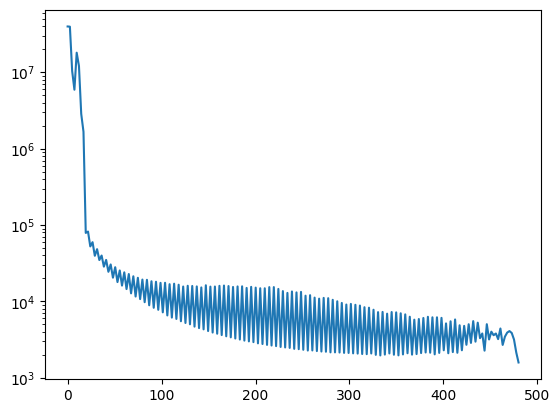

In [14]:
total,fluxes,times=tid_for_orbit(starship_orb,start_date,end_date)
plt.semilogy(times,fluxes)
